# Esercizio: Classificazione di Cifre Scritte a Mano con Keras

In questo esercizio, costruiremo e addestreremo un semplice modello di rete neurale utilizzando Keras per classificare le cifre scritte a mano del dataset MNIST.

Questo dataset contiene immagini in scala di grigi di cifre da 0 a 9, dimensionate a 28x28 pixel.

Obiettivi:

Caricare e preprocessare il dataset MNIST.

Costruire un modello sequenziale con strati densi.

Compilare il modello specificando ottimizzatore, funzione di perdita e metriche.

Addestrare il modello sui dati di addestramento.

Valutare le prestazioni del modello sui dati di test.

Utilizzare il modello per fare predizioni su nuove immagini.

In [ ]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import to_categorical
import matplotlib.pyplot as plt

## caricare e pre-elaborare il dataset

Spiegazione:

mnist.load_data(): Carica il dataset MNIST, suddiviso in training set e test set.

Visualizzazione: Mostra una delle immagini per avere un'idea dei dati.

Normalizzazione: Porta i valori dei pixel nell'intervallo [0, 1] per facilitare l'addestramento.
NELLE RETI NEURALI VANNO SEMPRE NORMALIZZATI

Reshape: Appiattisce ogni immagine 28x28 in un vettore di 784 elementi.

to_categorical: Converte le etichette in vettori binari per la classificazione multiclasse.

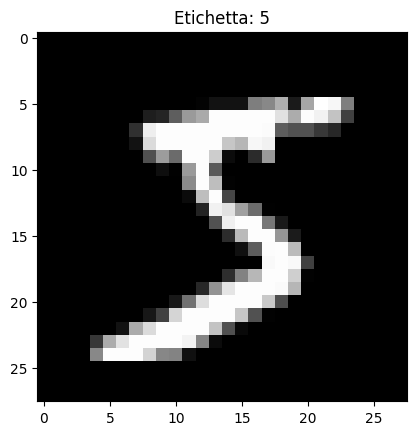

In [3]:
# Caricamento del dataset MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Visualizzazione di un esempio
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Etichetta: {y_train[0]}')
plt.show()

# Normalizzazione dei dati LE RETI NEURALI FUNZIONANO SOLO CON DATI NORMALIZZATI (anche non, ma molto piu difficile)
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Reshape dei dati
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# Conversione delle etichette in formato one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

## costruzione modello rete neurale

spiegazione: 

- Dense(units=128, activation='relu', input_shape=(784,)):
    - units=128: Numero di neuroni nello strato.
    - activation='relu': Funzione di attivazione ReLU per introdurre non linearità.
    - input_shape=(784,): Forma dell'input (vettore di 784 elementi).
    le foto sono 28x28 che fa 784, quindi la dimensione in input è 784, unico vettore composto dalle righe della matrice
- Strati Successivi: Aggiungiamo altri strati densi per aumentare la capacità di apprendimento del modello.
- Strato di Output: Con 10 neuroni e attivazione softmax per la classificazione su 10 classi.



In [4]:
# Creazione del modello
model = Sequential()

# Aggiunta degli strati
model.add(Dense(units=128, activation='relu', input_shape=(784,)))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

C:\Users\ilari\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## compilare il modello

Spiegazione:

optimizer='adam': Ottimizzatore che combina i vantaggi di AdaGrad e RMSProp.

loss='categorical_crossentropy': Funzione di perdita per la classificazione multiclasse.

metrics=['accuracy']: Monitoriamo l'accuratezza durante l'addestramento.

In [5]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## addestrare il modello

Spiegazione:

epochs=10: Il modello vede l'intero dataset 10 volte.

batch_size=32: Aggiorna i pesi ogni 32 campioni. non superare mai 128

validation_split=0.1: Utilizza il 10% dei dati di training per la validazione.


### history

la history si salva accuratezza e perdita, cosi da visualizzarli nei grafici dopo

In [6]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9259 - loss: 0.2575 - val_accuracy: 0.9652 - val_loss: 0.1235
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9668 - loss: 0.1097 - val_accuracy: 0.9748 - val_loss: 0.0849
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9769 - loss: 0.0749 - val_accuracy: 0.9748 - val_loss: 0.0798
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9814 - loss: 0.0578 - val_accuracy: 0.9780 - val_loss: 0.0850
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9854 - loss: 0.0445 - val_accuracy: 0.9750 - val_loss: 0.0952
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9875 - loss: 0.0377 - val_accuracy: 0.9777 - val_loss: 0.0944
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9905 - loss: 0.0285 - val_accuracy: 0.9782 - val_loss: 0.0834
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9918 - loss: 0.0247 - 

## valutare il modello

Spiegazione:

model.evaluate(): Valuta il modello sul test set e restituisce la perdita e l'accuratezza.

In [7]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Perdita sul test set: {test_loss:.4f}')
print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0988
Perdita sul test set: 0.0988
Accuratezza sul test set: 0.9763


## visualizzare le prestazioni

## grafico accuratezza

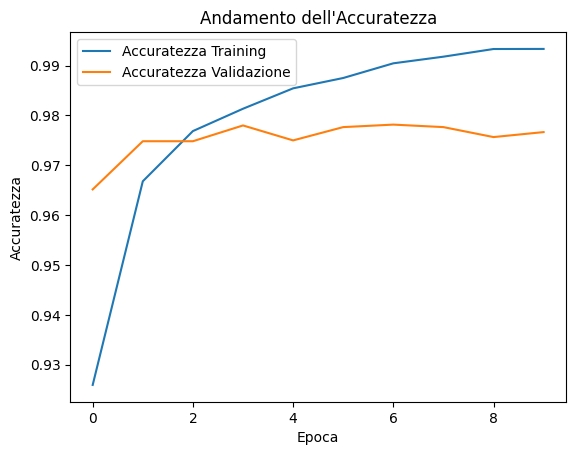

In [8]:
plt.plot(history.history['accuracy'],
label='Accuratezza Training')
plt.plot(history.history['val_accuracy'],
label='Accuratezza Validazione')
plt.xlabel('Epoca')
plt.ylabel('Accuratezza')
plt.legend()
plt.title('Andamento dell\'Accuratezza')
plt.show()

### analisi

piu è alta, meglio è 

quella blu è l'addestramento, dopo un po non riesce piu a fare di meglio

quello arancione è la validazione, resta abbastanza alta

## grafico perdita


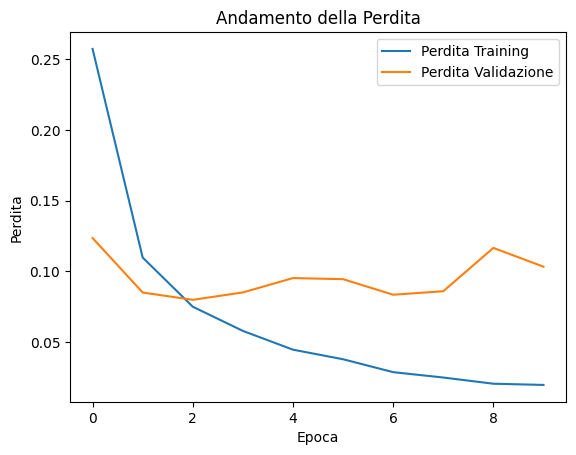

In [11]:
plt.plot(history.history['loss'], label='Perdita Training')
plt.plot(history.history['val_loss'], label='Perdita Validazione')
plt.xlabel('Epoca')
plt.ylabel('Perdita')
plt.legend()
plt.title('Andamento della Perdita')
plt.show()

### analisi

la perdita dell'addestramento scende sempre, mentre quella arancione di validazione resta costante, quindi ci dice che sta overfittando! 

se non perde nulla, vuol dire che è troppo bravo, quindi sta imparando a memoria i dati 